<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/013_serving_monitoring_mlops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Da experimentação a um serviço de inferência observável

**Área:** MLOps  
**Tipo de problema:** Serving, observabilidade e monitoramento de modelos

### Pergunta de estudo

> O que precisa existir ao redor de um modelo para que ele deixe de ser apenas um artefato de notebook e se torne um serviço de IA operável, observável e monitorável?

O foco deste estudo não é maximizar a performance do modelo.  
O objetivo é construir a infraestrutura mínima ao redor da inferência.

### Arquitetura

```text
Cliente
   ↓
FastAPI
   ↓
Schema validation
   ↓
Model inference
   ↓
Prediction
```

Camadas operacionais:

```text
              Model Service
                   │
       ┌───────────┼───────────┐
       ↓           ↓           ↓
     Logs        Metrics      Traces
    JSON        Prometheus  OpenTelemetry
       └───────────┼───────────┘
                   ↓
               Monitoring
                   ↓
          Drift + feedback real
```

### Componentes

- treinamento e versionamento;
- persistência segura do artefato;
- FastAPI;
- schemas Pydantic;
- `/predict`;
- liveness;
- readiness;
- metadados;
- logs estruturados;
- request IDs;
- Prometheus;
- histogramas de latência;
- OpenTelemetry;
- feature drift;
- delayed ground truth;
- testes funcionais;
- teste concorrente;
- Dockerfile;
- configuração de Prometheus.

### Princípio central

Em produção, não basta perguntar:

> O modelo prevê bem?

Também precisamos saber:

- está disponível?
- qual versão está servindo?
- qual é a latência?
- quantos erros ocorrem?
- os dados mudaram?
- quando chega ground truth, a qualidade permanece adequada?


## 1. Dependências

O serviço será testado **in-process**, portanto o Colab não precisa publicar uma porta externa.


In [1]:
!pip -q install -U scikit-learn skops fastapi uvicorn prometheus-client httpx opentelemetry-api opentelemetry-sdk opentelemetry-instrumentation-fastapi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.4.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.44.0 which is incompatible.
google-adk 2.4.0 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have 

## 2. Importações e versões

Registrar versões faz parte da reprodutibilidade do serving.


In [2]:
import asyncio
import hashlib
import importlib
import json
import platform
import random
import sys
from pathlib import Path

import httpx
import numpy as np
import pandas as pd
import sklearn
import skops
import skops.io as sio

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("skops:", skops.__version__)
print("httpx:", httpx.__version__)


Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 2.0.2
Pandas: 2.2.2
scikit-learn: 1.9.0
skops: 0.14.0
httpx: 0.28.1


# Parte A — Treinamento e artefato

O modelo será propositalmente simples:

**Iris → StandardScaler → Logistic Regression**

Assim, o foco permanece em MLOps.


## 3. Dataset


In [3]:
iris = load_iris(as_frame=True)

FEATURE_NAMES = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]

X = iris.data.copy()
X.columns = FEATURE_NAMES
y = iris.target.copy()

CLASS_NAMES = {
    int(i): str(name)
    for i, name in enumerate(iris.target_names)
}

print("Amostras:", len(X))
print("Features:", FEATURE_NAMES)
print("Classes:", CLASS_NAMES)

display(X.head())


Amostras: 150
Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Classes: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 4. Treinamento

O conjunto de treino também será a distribuição de referência para o monitor de drift.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y,
)

model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=SEED,
        ),
    ),
])

model.fit(X_train, y_train)

test_predictions = model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    test_predictions,
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
)

print(f"Accuracy: {test_accuracy:.4f}")
print(f"Macro F1: {test_f1:.4f}")
print()
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            CLASS_NAMES[i]
            for i in sorted(CLASS_NAMES)
        ],
    )
)


Accuracy: 0.9211
Macro F1: 0.9230

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



## 5. Persistência e versionamento

A previsão deve poder ser associada ao artefato que a produziu.

Registraremos:

- nome;
- versão;
- hash SHA-256;
- features;
- classes;
- métricas offline;
- versões de runtime.


In [5]:
SERVICE_DIR = Path("study013_service")
SERVICE_DIR.mkdir(exist_ok=True)

MODEL_PATH = SERVICE_DIR / "model.skops"
REFERENCE_PATH = SERVICE_DIR / "reference_features.npz"
METADATA_PATH = SERVICE_DIR / "metadata.json"

MODEL_NAME = "iris-logistic-regression"
MODEL_VERSION = "1.0.0"

sio.dump(model, MODEL_PATH)

np.savez_compressed(
    REFERENCE_PATH,
    X_reference=X_train[
        FEATURE_NAMES
    ].to_numpy(dtype="float64"),
)

artifact_sha256 = hashlib.sha256(
    MODEL_PATH.read_bytes()
).hexdigest()

metadata = {
    "model_name": MODEL_NAME,
    "model_version": MODEL_VERSION,
    "artifact_sha256": artifact_sha256,
    "feature_names": FEATURE_NAMES,
    "class_names": {
        str(k): v
        for k, v in CLASS_NAMES.items()
    },
    "offline_metrics": {
        "accuracy": float(test_accuracy),
        "macro_f1": float(test_f1),
    },
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "scikit_learn_version": sklearn.__version__,
    "python_version": sys.version.split()[0],
    "created_at_utc": pd.Timestamp.utcnow().isoformat(),
}

METADATA_PATH.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

display(pd.Series(metadata, name="value").to_frame())


,value
model_name,iris-logistic-regression
model_version,1.0.0
artifact_sha256,f9ea1fed0436a267203b56e9669f5b7d514993e6030ddf...
feature_names,"[sepal_length, sepal_width, petal_length, peta..."
class_names,"{'0': 'setosa', '1': 'versicolor', '2': 'virgi..."
offline_metrics,"{'accuracy': 0.9210526315789473, 'macro_f1': 0..."
training_rows,112
test_rows,38
scikit_learn_version,1.9.0
python_version,3.12.13


## 6. Inspeção do artefato

`skops.io` permite identificar tipos antes do carregamento.

> Em produção, tipos desconhecidos devem ser revisados; um serviço não deve confiar automaticamente em artefatos arbitrários.


In [6]:
unknown_types = sio.get_untrusted_types(
    file=MODEL_PATH
)

print("Tipos identificados:")
display(
    pd.Series(
        unknown_types,
        dtype="object",
        name="type",
    ).to_frame()
)


Tipos identificados:


,type


# Parte B — Serviço FastAPI

O serviço será criado como módulo Python real dentro do runtime.


## 7. Implementação do serviço

Endpoints:

- `GET /health/live`
- `GET /health/ready`
- `GET /model`
- `POST /predict`
- `POST /feedback`
- `GET /monitoring/drift`
- `GET /monitoring/feedback-summary`
- `GET /debug/logs`
- `GET /debug/traces`
- `/metrics`


In [7]:
%%writefile study013_service/app.py
from __future__ import annotations

import json
import logging
import threading
import time
import uuid
from collections import deque
from pathlib import Path
from typing import Literal

import numpy as np
import skops.io as sio

from fastapi import FastAPI, HTTPException, Request
from pydantic import BaseModel, Field

from prometheus_client import (
    CollectorRegistry,
    Counter,
    Gauge,
    Histogram,
    Info,
    make_asgi_app,
)

from opentelemetry import trace
from opentelemetry.instrumentation.fastapi import FastAPIInstrumentor
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import (
    SimpleSpanProcessor,
    SpanExporter,
    SpanExportResult,
)


# ----------------------------------------------------------
# Artifacts
# ----------------------------------------------------------

BASE_DIR = Path(__file__).resolve().parent

MODEL_PATH = BASE_DIR / "model.skops"
REFERENCE_PATH = BASE_DIR / "reference_features.npz"
METADATA_PATH = BASE_DIR / "metadata.json"

METADATA = json.loads(
    METADATA_PATH.read_text(encoding="utf-8")
)

FEATURE_NAMES = list(METADATA["feature_names"])

CLASS_NAMES = {
    int(k): v
    for k, v in METADATA["class_names"].items()
}

TRUSTED_TYPES = sio.get_untrusted_types(
    file=MODEL_PATH
)

# The artifact is generated inside the same trusted study.
# In production, review TRUSTED_TYPES explicitly.
MODEL = sio.load(
    MODEL_PATH,
    trusted=TRUSTED_TYPES,
)

REFERENCE_FEATURES = np.load(
    REFERENCE_PATH
)["X_reference"].astype("float64")

MODEL_LOADED = True
START_TIME = time.time()


# ----------------------------------------------------------
# Structured logs
# ----------------------------------------------------------

LOGGER = logging.getLogger("iris_model_service")
LOGGER.setLevel(logging.INFO)

if not LOGGER.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(message)s"))
    LOGGER.addHandler(handler)

STRUCTURED_LOGS = deque(maxlen=1000)


# ----------------------------------------------------------
# OpenTelemetry
# ----------------------------------------------------------

class MemorySpanExporter(SpanExporter):
    def __init__(self):
        self._spans = []
        self._lock = threading.Lock()

    def export(self, spans):
        with self._lock:
            self._spans.extend(spans)
        return SpanExportResult.SUCCESS

    def shutdown(self):
        return None

    def force_flush(self, timeout_millis=30000):
        return True

    def get_spans(self):
        with self._lock:
            return list(self._spans)

    def clear(self):
        with self._lock:
            self._spans.clear()


TRACE_EXPORTER = MemorySpanExporter()

TRACER_PROVIDER = TracerProvider()
TRACER_PROVIDER.add_span_processor(
    SimpleSpanProcessor(TRACE_EXPORTER)
)

TRACER = TRACER_PROVIDER.get_tracer(
    "iris-model-service"
)


# ----------------------------------------------------------
# Prometheus metrics
# ----------------------------------------------------------

PROM_REGISTRY = CollectorRegistry(auto_describe=True)

REQUESTS_TOTAL = Counter(
    "model_service_requests_total",
    "Total HTTP requests.",
    ["method", "endpoint", "status"],
    registry=PROM_REGISTRY,
)

REQUEST_LATENCY = Histogram(
    "model_service_request_duration_seconds",
    "HTTP request latency.",
    ["method", "endpoint"],
    buckets=(
        0.001,
        0.0025,
        0.005,
        0.01,
        0.025,
        0.05,
        0.1,
        0.25,
        0.5,
        1.0,
    ),
    registry=PROM_REGISTRY,
)

MODEL_LATENCY = Histogram(
    "model_inference_duration_seconds",
    "Time spent inside model inference.",
    buckets=(
        0.0001,
        0.00025,
        0.0005,
        0.001,
        0.0025,
        0.005,
        0.01,
        0.025,
        0.05,
        0.1,
    ),
    registry=PROM_REGISTRY,
)

PREDICTIONS_TOTAL = Counter(
    "model_predictions_total",
    "Predictions grouped by class.",
    ["predicted_class"],
    registry=PROM_REGISTRY,
)

FEEDBACK_TOTAL = Counter(
    "model_feedback_total",
    "Ground-truth feedback grouped by outcome.",
    ["outcome"],
    registry=PROM_REGISTRY,
)

FEATURE_PSI = Gauge(
    "model_feature_psi",
    "Population Stability Index per feature.",
    ["feature"],
    registry=PROM_REGISTRY,
)

DRIFT_DETECTED = Gauge(
    "model_feature_drift_detected",
    "1 when at least one feature exceeds the threshold.",
    registry=PROM_REGISTRY,
)

RECENT_WINDOW_SIZE = Gauge(
    "model_recent_feature_window_size",
    "Number of observations in the drift window.",
    registry=PROM_REGISTRY,
)

MODEL_BUILD_INFO = Info(
    "model_build",
    "Model artifact metadata.",
    registry=PROM_REGISTRY,
)

MODEL_BUILD_INFO.info({
    "model_name": METADATA["model_name"],
    "model_version": METADATA["model_version"],
    "artifact_sha256": METADATA["artifact_sha256"],
    "sklearn_version": METADATA["scikit_learn_version"],
})


# ----------------------------------------------------------
# Monitoring state
# ----------------------------------------------------------

FEATURE_BUFFER = deque(maxlen=200)
PREDICTION_STORE = {}

DRIFT_MIN_SAMPLES = 50

# Didactic operational threshold; calibrate per domain.
DRIFT_PSI_THRESHOLD = 0.20


def population_stability_index(
    reference: np.ndarray,
    current: np.ndarray,
    bins: int = 10,
) -> float:
    reference = np.asarray(reference, dtype="float64")
    current = np.asarray(current, dtype="float64")

    if len(reference) == 0 or len(current) == 0:
        return 0.0

    edges = np.unique(
        np.quantile(
            reference,
            np.linspace(0, 1, bins + 1),
        )
    )

    if len(edges) < 2:
        return 0.0

    edges = edges.astype("float64")
    edges[0] = -np.inf
    edges[-1] = np.inf

    ref_counts, _ = np.histogram(reference, bins=edges)
    cur_counts, _ = np.histogram(current, bins=edges)

    eps = 1e-6

    ref_pct = ref_counts / max(ref_counts.sum(), 1)
    cur_pct = cur_counts / max(cur_counts.sum(), 1)

    ref_pct = np.clip(ref_pct, eps, None)
    cur_pct = np.clip(cur_pct, eps, None)

    ref_pct = ref_pct / ref_pct.sum()
    cur_pct = cur_pct / cur_pct.sum()

    psi = np.sum(
        (cur_pct - ref_pct)
        * np.log(cur_pct / ref_pct)
    )

    return float(psi)


def compute_drift():
    window_size = len(FEATURE_BUFFER)
    RECENT_WINDOW_SIZE.set(window_size)

    if window_size < DRIFT_MIN_SAMPLES:
        DRIFT_DETECTED.set(0)

        return {
            "status": "insufficient_data",
            "window_size": window_size,
            "minimum_required": DRIFT_MIN_SAMPLES,
            "threshold": DRIFT_PSI_THRESHOLD,
            "features": {},
            "drift_detected": False,
        }

    current = np.asarray(
        FEATURE_BUFFER,
        dtype="float64",
    )

    scores = {}

    for feature_index, feature_name in enumerate(FEATURE_NAMES):
        psi = population_stability_index(
            REFERENCE_FEATURES[:, feature_index],
            current[:, feature_index],
        )

        FEATURE_PSI.labels(
            feature=feature_name
        ).set(psi)

        scores[feature_name] = psi

    drift_detected = any(
        score >= DRIFT_PSI_THRESHOLD
        for score in scores.values()
    )

    DRIFT_DETECTED.set(int(drift_detected))

    return {
        "status": "ok",
        "window_size": window_size,
        "threshold": DRIFT_PSI_THRESHOLD,
        "features": scores,
        "drift_detected": drift_detected,
    }


def reset_monitoring_state():
    FEATURE_BUFFER.clear()
    PREDICTION_STORE.clear()

    RECENT_WINDOW_SIZE.set(0)
    DRIFT_DETECTED.set(0)

    for feature_name in FEATURE_NAMES:
        FEATURE_PSI.labels(
            feature=feature_name
        ).set(0)


# ----------------------------------------------------------
# Schemas
# ----------------------------------------------------------

class PredictionRequest(BaseModel):
    sepal_length: float = Field(gt=0, lt=20)
    sepal_width: float = Field(gt=0, lt=20)
    petal_length: float = Field(gt=0, lt=20)
    petal_width: float = Field(gt=0, lt=20)


class PredictionResponse(BaseModel):
    prediction_id: str
    model_name: str
    model_version: str
    predicted_class: int
    predicted_label: str
    probabilities: dict[str, float]


class FeedbackRequest(BaseModel):
    prediction_id: str
    true_class: Literal[0, 1, 2]


# ----------------------------------------------------------
# API
# ----------------------------------------------------------

app = FastAPI(
    title="Iris Model Service",
    version=METADATA["model_version"],
)


@app.middleware("http")
async def request_observability(
    request: Request,
    call_next,
):
    request_id = (
        request.headers.get("x-request-id")
        or str(uuid.uuid4())
    )

    request.state.request_id = request_id

    started = time.perf_counter()
    status_code = 500

    try:
        response = await call_next(request)
        status_code = response.status_code

        response.headers["X-Request-ID"] = request_id
        return response

    finally:
        duration = time.perf_counter() - started
        endpoint = request.url.path

        if not endpoint.startswith("/metrics"):
            REQUESTS_TOTAL.labels(
                method=request.method,
                endpoint=endpoint,
                status=str(status_code),
            ).inc()

            REQUEST_LATENCY.labels(
                method=request.method,
                endpoint=endpoint,
            ).observe(duration)

        current_span = trace.get_current_span()
        span_context = current_span.get_span_context()

        trace_id = (
            format(span_context.trace_id, "032x")
            if span_context.is_valid
            else None
        )

        record = {
            "timestamp": time.time(),
            "level": "INFO",
            "event": "http_request",
            "request_id": request_id,
            "trace_id": trace_id,
            "method": request.method,
            "endpoint": endpoint,
            "status": status_code,
            "duration_ms": round(duration * 1000, 3),
            "model_version": METADATA["model_version"],
        }

        STRUCTURED_LOGS.append(record)

        LOGGER.info(
            json.dumps(
                record,
                separators=(",", ":"),
            )
        )


@app.get("/health/live")
def health_live():
    return {
        "status": "alive",
        "uptime_seconds": time.time() - START_TIME,
    }


@app.get("/health/ready")
def health_ready():
    if not MODEL_LOADED:
        raise HTTPException(
            status_code=503,
            detail="Model is not loaded.",
        )

    return {
        "status": "ready",
        "model_version": METADATA["model_version"],
        "feature_count": len(FEATURE_NAMES),
    }


@app.get("/model")
def model_metadata():
    return METADATA


@app.post(
    "/predict",
    response_model=PredictionResponse,
)
def predict(payload: PredictionRequest):
    feature_vector = np.asarray([
        payload.sepal_length,
        payload.sepal_width,
        payload.petal_length,
        payload.petal_width,
    ], dtype="float64")

    with TRACER.start_as_current_span(
        "model.predict"
    ) as span:
        span.set_attribute(
            "model.name",
            METADATA["model_name"],
        )
        span.set_attribute(
            "model.version",
            METADATA["model_version"],
        )

        started = time.perf_counter()

        probabilities = MODEL.predict_proba(
            feature_vector.reshape(1, -1)
        )[0]

        predicted_class = int(
            np.argmax(probabilities)
        )

        inference_duration = (
            time.perf_counter() - started
        )

        MODEL_LATENCY.observe(
            inference_duration
        )

        span.set_attribute(
            "model.predicted_class",
            predicted_class,
        )
        span.set_attribute(
            "model.inference_ms",
            inference_duration * 1000,
        )

    PREDICTIONS_TOTAL.labels(
        predicted_class=str(predicted_class)
    ).inc()

    FEATURE_BUFFER.append(
        feature_vector.tolist()
    )

    RECENT_WINDOW_SIZE.set(
        len(FEATURE_BUFFER)
    )

    prediction_id = str(uuid.uuid4())

    PREDICTION_STORE[prediction_id] = {
        "predicted_class": predicted_class,
        "true_class": None,
    }

    probability_payload = {
        CLASS_NAMES[class_index]:
            float(probabilities[class_index])
        for class_index in sorted(CLASS_NAMES)
    }

    return PredictionResponse(
        prediction_id=prediction_id,
        model_name=METADATA["model_name"],
        model_version=METADATA["model_version"],
        predicted_class=predicted_class,
        predicted_label=CLASS_NAMES[predicted_class],
        probabilities=probability_payload,
    )


@app.post("/feedback")
def submit_feedback(payload: FeedbackRequest):
    stored = PREDICTION_STORE.get(
        payload.prediction_id
    )

    if stored is None:
        raise HTTPException(
            status_code=404,
            detail="Unknown prediction_id.",
        )

    if stored["true_class"] is not None:
        raise HTTPException(
            status_code=409,
            detail="Feedback already submitted.",
        )

    stored["true_class"] = int(
        payload.true_class
    )

    correct = (
        stored["predicted_class"]
        == int(payload.true_class)
    )

    FEEDBACK_TOTAL.labels(
        outcome=(
            "correct"
            if correct
            else "incorrect"
        )
    ).inc()

    return {
        "status": "accepted",
        "correct": correct,
    }


@app.get("/monitoring/drift")
def monitoring_drift():
    with TRACER.start_as_current_span(
        "monitoring.feature_drift"
    ):
        return compute_drift()


@app.get("/monitoring/feedback-summary")
def feedback_summary():
    labeled = [
        record
        for record in PREDICTION_STORE.values()
        if record["true_class"] is not None
    ]

    if not labeled:
        return {
            "status": "insufficient_data",
            "labeled_predictions": 0,
            "accuracy": None,
        }

    correct = sum(
        record["predicted_class"]
        == record["true_class"]
        for record in labeled
    )

    return {
        "status": "ok",
        "labeled_predictions": len(labeled),
        "correct": int(correct),
        "accuracy": correct / len(labeled),
    }


@app.get("/debug/logs")
def debug_logs(limit: int = 20):
    limit = max(1, min(int(limit), 100))

    return {
        "records":
            list(STRUCTURED_LOGS)[-limit:]
    }


@app.get("/debug/traces")
def debug_traces(limit: int = 20):
    spans = TRACE_EXPORTER.get_spans()[-limit:]
    records = []

    for span in spans:
        parent_id = (
            span.parent.span_id
            if span.parent
            else None
        )

        records.append({
            "name": span.name,
            "trace_id": format(
                span.context.trace_id,
                "032x",
            ),
            "span_id": format(
                span.context.span_id,
                "016x",
            ),
            "parent_span_id": (
                format(parent_id, "016x")
                if parent_id
                else None
            ),
            "duration_ms": (
                (span.end_time - span.start_time)
                / 1_000_000
                if span.end_time is not None
                else None
            ),
            "attributes": dict(
                span.attributes or {}
            ),
        })

    return {"spans": records}


metrics_app = make_asgi_app(
    registry=PROM_REGISTRY
)

app.mount(
    "/metrics",
    metrics_app,
)

FastAPIInstrumentor.instrument_app(
    app,
    tracer_provider=TRACER_PROVIDER,
    excluded_urls=(
        "health/live,"
        "health/ready,"
        "metrics"
    ),
)


Writing study013_service/app.py


## 8. Importar o serviço


In [8]:
service_path = str(Path.cwd())

if service_path not in sys.path:
    sys.path.insert(0, service_path)

service = importlib.import_module(
    "study013_service.app"
)

app = service.app

print("Model loaded:", service.MODEL_LOADED)
print(
    "Model version:",
    service.METADATA["model_version"],
)


Model loaded: True
Model version: 1.0.0


# Parte C — Contrato e testes funcionais


In [9]:
from fastapi.testclient import TestClient

client = TestClient(app)


## 9. Liveness e readiness

- **Liveness:** o processo está vivo?
- **Readiness:** o serviço está pronto para tráfego e o modelo está carregado?


In [10]:
live_response = client.get("/health/live")
ready_response = client.get("/health/ready")

print("Liveness:", live_response.status_code, live_response.json())
print("Readiness:", ready_response.status_code, ready_response.json())

assert live_response.status_code == 200
assert ready_response.status_code == 200
assert ready_response.json()["model_version"] == MODEL_VERSION


{"timestamp":1786716406.2237995,"level":"INFO","event":"http_request","request_id":"91d715d9-138a-435b-ade5-599eebb85741","trace_id":null,"method":"GET","endpoint":"/health/live","status":200,"duration_ms":1.93,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.2237995,"level":"INFO","event":"http_request","request_id":"91d715d9-138a-435b-ade5-599eebb85741","trace_id":null,"method":"GET","endpoint":"/health/live","status":200,"duration_ms":1.93,"model_version":"1.0.0"}
{"timestamp":1786716406.2373257,"level":"INFO","event":"http_request","request_id":"6cd374fe-35cb-4c40-a879-07b257d52c07","trace_id":null,"method":"GET","endpoint":"/health/ready","status":200,"duration_ms":1.458,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.2373257,"level":"INFO","event":"http_request","request_id":"6cd374fe-35cb-4c40-a879-07b257d52c07","trace_id":null,"method":"GET","endpoint":"/health/ready","status":200,"duration_ms":1.458,"model_version":"1.0.0"}


Liveness: 200 {'status': 'alive', 'uptime_seconds': 0.23993635177612305}
Readiness: 200 {'status': 'ready', 'model_version': '1.0.0', 'feature_count': 4}


## 10. Validação de schema

Payloads inválidos devem ser rejeitados antes da inferência.


In [11]:
invalid_response = client.post(
    "/predict",
    json={
        "sepal_length": -5,
        "sepal_width": 3.0,
        "petal_length": 1.4,
        "petal_width": 0.2,
    },
)

print("Status:", invalid_response.status_code)
display(
    pd.json_normalize(
        invalid_response.json()["detail"]
    )
)

assert invalid_response.status_code == 422


{"timestamp":1786716406.2655954,"level":"INFO","event":"http_request","request_id":"a6dfe242-ebd4-4a85-9354-3509a7149b30","trace_id":"bdd640fb06671ad11c80317fa3b1799d","method":"POST","endpoint":"/predict","status":422,"duration_ms":4.572,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.2655954,"level":"INFO","event":"http_request","request_id":"a6dfe242-ebd4-4a85-9354-3509a7149b30","trace_id":"bdd640fb06671ad11c80317fa3b1799d","method":"POST","endpoint":"/predict","status":422,"duration_ms":4.572,"model_version":"1.0.0"}


Status: 422


,type,loc,msg,input,ctx.gt
0,greater_than,"[body, sepal_length]",Input should be greater than 0,-5,0.0


## 11. Inferência válida e versionada


In [12]:
sample_row = X_test.iloc[0]

prediction_payload = {
    feature:
        float(sample_row[feature])
    for feature in FEATURE_NAMES
}

prediction_response = client.post(
    "/predict",
    json=prediction_payload,
)

prediction_json = prediction_response.json()

display(
    pd.Series(
        prediction_json,
        name="value",
    ).to_frame()
)

assert prediction_response.status_code == 200
assert prediction_json["model_version"] == MODEL_VERSION

assert abs(
    sum(
        prediction_json[
            "probabilities"
        ].values()
    )
    - 1.0
) < 1e-6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716406.3226886,"level":"INFO","event":"http_request","request_id":"e0590e7a-798f-4fac-b556-1227bdb1e92a","trace_id":"0822e8f36c031199972a846916419f82","method":"POST","endpoint":"/predict","status":200,"duration_ms":5.717,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.3226886,"level":"INFO","event":"http_request","request_id":"e0590e7a-798f-4fac-b556-1227bdb1e92a","trace_id":"0822e8f36c031199972a846916419f82","method":"POST","endpoint":"/predict","status":200,"duration_ms":5.717,"model_version":"1.0.0"}


,value
prediction_id,0ae1ca8c-aed1-49dc-93c1-34080071f568
model_name,iris-logistic-regression
model_version,1.0.0
predicted_class,0
predicted_label,setosa
probabilities,"{'setosa': 0.984578819914545, 'versicolor': 0...."


## 12. Request ID

O cliente pode fornecer um ID de correlação, e o serviço o devolve.


In [13]:
custom_request_id = "study013-demo-001"

response = client.post(
    "/predict",
    headers={
        "X-Request-ID":
            custom_request_id
    },
    json=prediction_payload,
)

returned_request_id = (
    response.headers.get(
        "x-request-id"
    )
)

print(
    "Returned X-Request-ID:",
    returned_request_id,
)

assert (
    returned_request_id
    == custom_request_id
)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716406.363561,"level":"INFO","event":"http_request","request_id":"study013-demo-001","trace_id":"72ff5d2a386ecbe06b65a6a48b8148f6","method":"POST","endpoint":"/predict","status":200,"duration_ms":4.656,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.363561,"level":"INFO","event":"http_request","request_id":"study013-demo-001","trace_id":"72ff5d2a386ecbe06b65a6a48b8148f6","method":"POST","endpoint":"/predict","status":200,"duration_ms":4.656,"model_version":"1.0.0"}


Returned X-Request-ID: study013-demo-001


# Parte D — Logs, metrics e traces


## 13. Logs estruturados

O serviço registra metadados operacionais, mas não grava as features brutas.


In [14]:
logs = client.get(
    "/debug/logs",
    params={"limit": 8},
).json()["records"]

display(pd.DataFrame(logs))


{"timestamp":1786716406.3908722,"level":"INFO","event":"http_request","request_id":"1730ab74-92e6-410f-850c-82f08a5154fc","trace_id":"c37459eef50bea63371ecd7b27cd8130","method":"GET","endpoint":"/debug/logs","status":200,"duration_ms":2.183,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.3908722,"level":"INFO","event":"http_request","request_id":"1730ab74-92e6-410f-850c-82f08a5154fc","trace_id":"c37459eef50bea63371ecd7b27cd8130","method":"GET","endpoint":"/debug/logs","status":200,"duration_ms":2.183,"model_version":"1.0.0"}


,timestamp,level,event,request_id,trace_id,method,endpoint,status,duration_ms,model_version
0,1.786716e+09,INFO,http_request,91d715d9-138a-435b-ade5-599eebb85741,None,GET,/health/live,200,1.930,1.0.0
1,1.786716e+09,INFO,http_request,6cd374fe-35cb-4c40-a879-07b257d52c07,None,GET,/health/ready,200,1.458,1.0.0
2,1.786716e+09,INFO,http_request,a6dfe242-ebd4-4a85-9354-3509a7149b30,bdd640fb06671ad11c80317fa3b1799d,POST,/predict,422,4.572,1.0.0
3,1.786716e+09,INFO,http_request,e0590e7a-798f-4fac-b556-1227bdb1e92a,0822e8f36c031199972a846916419f82,POST,/predict,200,5.717,1.0.0
4,1.786716e+09,INFO,http_request,study013-demo-001,72ff5d2a386ecbe06b65a6a48b8148f6,POST,/predict,200,4.656,1.0.0


## 14. Prometheus

São expostos:

- requests;
- latência HTTP;
- latência de inferência;
- distribuição de classes;
- feedback;
- drift;
- metadata do modelo.


In [15]:
metrics_response = client.get("/metrics")

print("Status:", metrics_response.status_code)

metrics_text = metrics_response.text

selected_lines = [
    line
    for line in metrics_text.splitlines()
    if any(
        name in line
        for name in [
            "model_service_requests_total",
            "model_inference_duration_seconds",
            "model_predictions_total",
            "model_build_info",
        ]
    )
]

print("\n".join(selected_lines[:30]))


{"timestamp":1786716406.4475133,"level":"INFO","event":"http_request","request_id":"865b3ea9-3351-4b35-8e70-b5290fd29656","trace_id":null,"method":"GET","endpoint":"/metrics","status":307,"duration_ms":0.466,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.4475133,"level":"INFO","event":"http_request","request_id":"865b3ea9-3351-4b35-8e70-b5290fd29656","trace_id":null,"method":"GET","endpoint":"/metrics","status":307,"duration_ms":0.466,"model_version":"1.0.0"}
{"timestamp":1786716406.4584935,"level":"INFO","event":"http_request","request_id":"25038f09-03a0-4648-a9fe-3c89c418cb03","trace_id":null,"method":"GET","endpoint":"/metrics/","status":200,"duration_ms":3.391,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.4584935,"level":"INFO","event":"http_request","request_id":"25038f09-03a0-4648-a9fe-3c89c418cb03","trace_id":null,"method":"GET","endpoint":"/metrics/","status":200,"duration_ms":3.391,"model_version":"1.0.0"}


Status: 200
# HELP model_service_requests_total Total HTTP requests.
# TYPE model_service_requests_total counter
model_service_requests_total{endpoint="/health/live",method="GET",status="200"} 1.0
model_service_requests_total{endpoint="/health/ready",method="GET",status="200"} 1.0
model_service_requests_total{endpoint="/predict",method="POST",status="422"} 1.0
model_service_requests_total{endpoint="/predict",method="POST",status="200"} 2.0
model_service_requests_total{endpoint="/debug/logs",method="GET",status="200"} 1.0
# HELP model_inference_duration_seconds Time spent inside model inference.
# TYPE model_inference_duration_seconds histogram
model_inference_duration_seconds_bucket{le="0.0001"} 0.0
model_inference_duration_seconds_bucket{le="0.00025"} 0.0
model_inference_duration_seconds_bucket{le="0.0005"} 0.0
model_inference_duration_seconds_bucket{le="0.001"} 0.0
model_inference_duration_seconds_bucket{le="0.0025"} 1.0
model_inference_duration_seconds_bucket{le="0.005"} 2.0
model_i

## 15. OpenTelemetry

FastAPI recebe instrumentação automática e a inferência cria um span manual `model.predict`.

Neste estudo, spans ficam em memória para inspeção.


In [16]:
_ = client.post(
    "/predict",
    json=prediction_payload,
)

traces = client.get(
    "/debug/traces",
    params={"limit": 20},
).json()["spans"]

trace_df = pd.DataFrame(traces)

display(
    trace_df[
        [
            column
            for column in [
                "name",
                "trace_id",
                "span_id",
                "parent_span_id",
                "duration_ms",
            ]
            if column in trace_df.columns
        ]
    ]
)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716406.4836512,"level":"INFO","event":"http_request","request_id":"08560ef5-23cb-44a1-9ea7-87fe34972c19","trace_id":"0b1f9163ce9ff57f43b7a3a69a8dca03","method":"POST","endpoint":"/predict","status":200,"duration_ms":4.31,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716406.4836512,"level":"INFO","event":"http_request","request_id":"08560ef5-23cb-44a1-9ea7-87fe34972c19","trace_id":"0b1f9163ce9ff57f43b7a3a69a8dca03","method":"POST","endpoint":"/predict","status":200,"duration_ms":4.31,"model_version":"1.0.0"}
{"timestamp":1786716406.4982822,"level":"INFO","event":"http_request","request_id":"5b85e28a-21d0-4f19-b168-fbf8f93296e7","trace_id":"5c941cf0dc98d2c1e2acf72f9e574f7a","method":"GET","endpoint":"/debug/traces","status":200,"duration_ms":4.301,"model_version":"

,name,trace_id,span_id,parent_span_id,duration_ms
0,POST /predict http send,0822e8f36c031199972a846916419f82,8fadc1a606cb0fb3,17fc695a07a0ca6e,0.077461
1,POST /predict http send,0822e8f36c031199972a846916419f82,b74d0fb132e70629,17fc695a07a0ca6e,0.031015
2,POST /predict http send,0822e8f36c031199972a846916419f82,b38a088ca65ed389,17fc695a07a0ca6e,0.017926
3,POST /predict,0822e8f36c031199972a846916419f82,17fc695a07a0ca6e,None,11.171128
4,POST /predict http receive,72ff5d2a386ecbe06b65a6a48b8148f6,de8a774bcf36d58b,4737819096da1dac,0.035776
5,model.predict,72ff5d2a386ecbe06b65a6a48b8148f6,c241330b01a9e71f,4737819096da1dac,1.760408
6,POST /predict http send,72ff5d2a386ecbe06b65a6a48b8148f6,28df6ec4ce4a2bbd,4737819096da1dac,0.060525
7,POST /predict http send,72ff5d2a386ecbe06b65a6a48b8148f6,6c307511b2b9437a,4737819096da1dac,0.020442
8,POST /predict http send,72ff5d2a386ecbe06b65a6a48b8148f6,47229389571aa876,4737819096da1dac,0.015507
9,POST /predict,72ff5d2a386ecbe06b65a6a48b8148f6,4737819096da1dac,None,8.397292


# Parte E — Teste concorrente

O benchmark é **in-process**: mede aplicação + modelo, sem rede externa.

Ele serve para comparação entre versões do estudo, não como capacidade real de produção.


In [17]:
load_test_rows = X_test.sample(
    n=20,
    replace=True,
    random_state=SEED,
)

LOAD_PAYLOADS = [
    {
        feature: float(row[feature])
        for feature in FEATURE_NAMES
    }
    for _, row
    in load_test_rows.iterrows()
]


In [18]:
async def run_load_test(
    total_requests=200,
    concurrency=25,
):
    transport = httpx.ASGITransport(
        app=app
    )

    semaphore = asyncio.Semaphore(
        concurrency
    )

    latencies = []
    statuses = []

    async with httpx.AsyncClient(
        transport=transport,
        base_url="http://test",
        timeout=30.0,
    ) as async_client:

        async def one_request(i):
            payload = LOAD_PAYLOADS[
                i % len(LOAD_PAYLOADS)
            ]

            async with semaphore:
                started = (
                    asyncio.get_running_loop()
                    .time()
                )

                response = await async_client.post(
                    "/predict",
                    json=payload,
                )

                elapsed = (
                    asyncio.get_running_loop()
                    .time()
                    - started
                )

                latencies.append(elapsed)
                statuses.append(
                    response.status_code
                )

        started = (
            asyncio.get_running_loop()
            .time()
        )

        await asyncio.gather(
            *[
                one_request(i)
                for i in range(total_requests)
            ]
        )

        total_elapsed = (
            asyncio.get_running_loop()
            .time()
            - started
        )

    latency_ms = (
        np.asarray(latencies)
        * 1000
    )

    return {
        "requests": total_requests,
        "concurrency": concurrency,
        "total_time_s": total_elapsed,
        "throughput_rps":
            total_requests / total_elapsed,
        "error_rate":
            np.mean(
                np.asarray(statuses) >= 400
            ),
        "p50_ms":
            np.percentile(latency_ms, 50),
        "p95_ms":
            np.percentile(latency_ms, 95),
        "p99_ms":
            np.percentile(latency_ms, 99),
    }


load_test_result = await run_load_test(
    total_requests=200,
    concurrency=25,
)

display(
    pd.Series(
        load_test_result,
        name="value",
    ).to_frame()
)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,value
requests,200.000000
concurrency,25.000000
total_time_s,3.087627
throughput_rps,64.774663
error_rate,0.000000
p50_ms,383.411191
p95_ms,546.333418
p99_ms,565.443352


# Parte F — Feature drift

O serviço mantém uma janela recente e compara as features com a distribuição de treino usando **Population Stability Index (PSI)**.

O threshold do notebook é apenas didático; thresholds de produção precisam ser calibrados.


## 16. Tráfego semelhante à referência


In [19]:
service.reset_monitoring_state()

rng = np.random.default_rng(SEED)

indices = rng.choice(
    len(X_train),
    size=80,
    replace=True,
)

normal_batch = X_train.iloc[indices]

for _, row in normal_batch.iterrows():
    payload = {
        feature: float(row[feature])
        for feature in FEATURE_NAMES
    }

    response = client.post(
        "/predict",
        json=payload,
    )

    assert response.status_code == 200

normal_drift = client.get(
    "/monitoring/drift"
).json()

display(
    pd.Series(
        normal_drift,
        name="value",
    ).to_frame()
)

display(
    pd.Series(
        normal_drift["features"],
        name="PSI",
    ).sort_values(
        ascending=False
    ).to_frame()
)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716409.7947237,"level":"INFO","event":"http_request","request_id":"089bece1-b405-4df5-ae8c-152016d7782c","trace_id":"225aed6cf0458043e3a68a707e710b55","method":"POST","endpoint":"/predict","status":200,"duration_ms":19.684,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716409.7947237,"level":"INFO","event":"http_request","request_id":"089bece1-b405-4df5-ae8c-152016d7782c","trace_id":"225aed6cf0458043e3a68a707e710b55","method":"POST","endpoint":"/predict","status":200,"duration_ms":19.684,"model_version":"1.0.0"}
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716409.8316102,"level":"INFO","event":"http_reque

,value
status,ok
window_size,80
threshold,0.2
features,"{'sepal_length': 0.07807762989986045, 'sepal_w..."
drift_detected,False


,PSI
sepal_width,0.088153
sepal_length,0.078078
petal_length,0.071850
petal_width,0.020339


## 17. Drift artificial

Agora deslocamos propositalmente parte das features apenas para validar o detector.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716857.6696148,"level":"INFO","event":"http_request","request_id":"4be7a0ad-3348-4fa5-8a40-f6ee038cbe04","trace_id":"79a7e63bbee975da0c9e55503cd1ff3f","method":"POST","endpoint":"/predict","status":200,"duration_ms":5.412,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716857.6696148,"level":"INFO","event":"http_request","request_id":"4be7a0ad-3348-4fa5-8a40-f6ee038cbe04","trace_id":"79a7e63bbee975da0c9e55503cd1ff3f","method":"POST","endpoint":"/predict","status":200,"duration_ms":5.412,"model_version":"1.0.0"}
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716857.683909,"level":"INFO","event":"http_request"

,Normal PSI,Shifted PSI
sepal_length,0.0781,8.8890
sepal_width,0.0882,0.1248
petal_length,0.0719,7.5314
petal_width,0.0203,6.7587


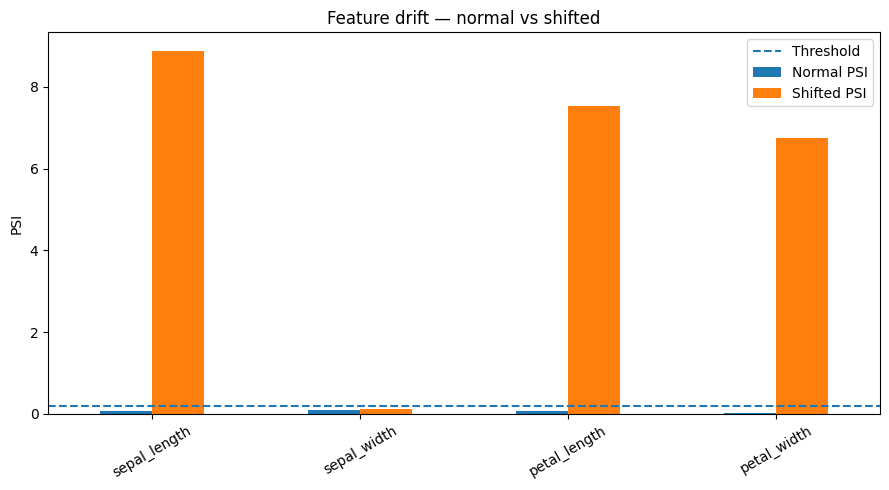

In [21]:
import matplotlib.pyplot as plt

service.reset_monitoring_state()

shifted_batch = (
    X_train.sample(
        n=80,
        replace=True,
        random_state=SEED + 1,
    )
    .copy()
)

shifted_batch["sepal_length"] += 2.0
shifted_batch["petal_length"] += 2.5
shifted_batch["petal_width"] += 0.8

for _, row in shifted_batch.iterrows():
    payload = {
        feature: float(row[feature])
        for feature in FEATURE_NAMES
    }

    response = client.post(
        "/predict",
        json=payload,
    )

    assert response.status_code == 200

shifted_drift = client.get(
    "/monitoring/drift"
).json()

drift_comparison = pd.DataFrame({
    "Normal PSI":
        normal_drift["features"],
    "Shifted PSI":
        shifted_drift["features"],
})

display(drift_comparison.round(4))

drift_comparison.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.axhline(
    service.DRIFT_PSI_THRESHOLD,
    linestyle="--",
    label="Threshold",
)

plt.title(
    "Feature drift — normal vs shifted"
)
plt.ylabel("PSI")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


## 18. Drift não é performance

Uma mudança nas entradas não prova que a qualidade caiu.

Para medir performance real, precisamos de **ground truth**.


# Parte G — Delayed ground truth

O endpoint `/predict` devolve um `prediction_id`.

Quando o rótulo verdadeiro chega depois, `/feedback` liga o resultado real à previsão original.


In [22]:
service.reset_monitoring_state()

feedback_sample = (
    X_test.copy()
    .assign(true_class=y_test)
    .sample(
        n=min(30, len(X_test)),
        random_state=SEED,
    )
)

feedback_records = []

for _, row in feedback_sample.iterrows():
    payload = {
        feature: float(row[feature])
        for feature in FEATURE_NAMES
    }

    prediction = client.post(
        "/predict",
        json=payload,
    ).json()

    feedback_records.append({
        "prediction_id":
            prediction["prediction_id"],
        "predicted_class":
            prediction["predicted_class"],
        "true_class":
            int(row["true_class"]),
    })

feedback_records_df = pd.DataFrame(
    feedback_records
)

display(feedback_records_df.head())


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716860.5333183,"level":"INFO","event":"http_request","request_id":"d55346a3-45b4-41a0-957a-eb5eeaf6ef8d","trace_id":"38491ecc889157fd2804d0ac795741bb","method":"POST","endpoint":"/predict","status":200,"duration_ms":4.724,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716860.5333183,"level":"INFO","event":"http_request","request_id":"d55346a3-45b4-41a0-957a-eb5eeaf6ef8d","trace_id":"38491ecc889157fd2804d0ac795741bb","method":"POST","endpoint":"/predict","status":200,"duration_ms":4.724,"model_version":"1.0.0"}
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
{"timestamp":1786716860.5500684,"level":"INFO","event":"http_request

,prediction_id,predicted_class,true_class
0,a4e7f2e6-cd5b-4084-8c40-1f19b033ad8b,0,0
1,272fbdf5-6777-45b1-81a2-def0ba6dad13,2,2
2,245869e2-6f52-451f-868e-260443cc7161,0,0
3,04790fd1-0d0b-46ec-baa4-16eac42e7980,1,1
4,ee72ce46-2e92-4ed6-b7e2-e96af105a17b,2,2


In [23]:
for _, row in feedback_records_df.iterrows():
    response = client.post(
        "/feedback",
        json={
            "prediction_id":
                row["prediction_id"],
            "true_class":
                int(row["true_class"]),
        },
    )

    assert response.status_code == 200

feedback_summary = client.get(
    "/monitoring/feedback-summary"
).json()

offline_feedback_accuracy = (
    feedback_records_df[
        "predicted_class"
    ]
    ==
    feedback_records_df[
        "true_class"
    ]
).mean()

display(
    pd.Series(
        feedback_summary,
        name="value",
    ).to_frame()
)

print(
    "Accuracy recalculada:",
    offline_feedback_accuracy,
)

assert abs(
    feedback_summary["accuracy"]
    - offline_feedback_accuracy
) < 1e-12


{"timestamp":1786716861.2922952,"level":"INFO","event":"http_request","request_id":"87b335ce-8d71-433d-854b-e74d36dd361d","trace_id":"9929afeb48842a14157511addbeae9f8","method":"POST","endpoint":"/feedback","status":200,"duration_ms":3.48,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716861.2922952,"level":"INFO","event":"http_request","request_id":"87b335ce-8d71-433d-854b-e74d36dd361d","trace_id":"9929afeb48842a14157511addbeae9f8","method":"POST","endpoint":"/feedback","status":200,"duration_ms":3.48,"model_version":"1.0.0"}
{"timestamp":1786716861.3036604,"level":"INFO","event":"http_request","request_id":"3e26ad88-e638-4ecd-a191-0da1b550aef6","trace_id":"850f1cdc1e2a03f185c5391093f6f723","method":"POST","endpoint":"/feedback","status":200,"duration_ms":2.107,"model_version":"1.0.0"}
INFO:iris_model_service:{"timestamp":1786716861.3036604,"level":"INFO","event":"http_request","request_id":"3e26ad88-e638-4ecd-a191-0da1b550aef6","trace_id":"850f1cdc1e2a03f185c539109

,value
status,ok
labeled_predictions,30
correct,28
accuracy,0.933333


Accuracy recalculada: 0.9333333333333333


# Parte H — Deployment artifacts


## 19. `requirements.txt`


In [24]:
requirements_text = """fastapi
uvicorn[standard]
numpy
scikit-learn
skops
prometheus-client
opentelemetry-api
opentelemetry-sdk
opentelemetry-instrumentation-fastapi
"""

(
    SERVICE_DIR
    / "requirements.txt"
).write_text(
    requirements_text,
    encoding="utf-8",
)

print(requirements_text)


fastapi
uvicorn[standard]
numpy
scikit-learn
skops
prometheus-client
opentelemetry-api
opentelemetry-sdk
opentelemetry-instrumentation-fastapi



## 20. `Dockerfile`


In [25]:
dockerfile_text = """FROM python:3.12-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY model.skops .
COPY metadata.json .
COPY reference_features.npz .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

(
    SERVICE_DIR
    / "Dockerfile"
).write_text(
    dockerfile_text,
    encoding="utf-8",
)

print(dockerfile_text)


FROM python:3.12-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY model.skops .
COPY metadata.json .
COPY reference_features.npz .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



## 21. `prometheus.yml`


In [26]:
prometheus_text = """global:
  scrape_interval: 15s

scrape_configs:
  - job_name: iris-model-service
    metrics_path: /metrics
    static_configs:
      - targets:
          - model-service:8000
"""

(
    SERVICE_DIR
    / "prometheus.yml"
).write_text(
    prometheus_text,
    encoding="utf-8",
)

print(prometheus_text)


global:
  scrape_interval: 15s

scrape_configs:
  - job_name: iris-model-service
    metrics_path: /metrics
    static_configs:
      - targets:
          - model-service:8000



## 22. Inventário do serviço


In [27]:
service_files = []

for file_path in sorted(
    SERVICE_DIR.iterdir()
):
    if file_path.is_file():
        service_files.append({
            "file": file_path.name,
            "size_bytes":
                file_path.stat().st_size,
        })

display(pd.DataFrame(service_files))


,file,size_bytes
0,Dockerfile,277
1,app.py,16087
2,metadata.json,617
3,model.skops,26105
4,prometheus.yml,176
5,reference_features.npz,976
6,requirements.txt,143


# Parte I — Arquitetura de produção

Uma evolução real poderia separar os componentes:

```text
Load Balancer
     ↓
Model Service
  ┌──┼───────────────┐
  ↓  ↓               ↓
Logs Prometheus   OpenTelemetry
  ↓      ↓             ↓
Log DB Grafana      Trace backend
         ↓
       Alerts
```

E o fluxo de qualidade:

```text
Requests
   ↓
Feature events
   ↓
Drift monitor
   ↓
Ground truth arrives
   ↓
Performance monitor
   ↓
Investigation
   ↓
Retraining decision
```

### Importante

`drift detectado` não deve significar automaticamente `retreinar`.

Retreinamento precisa de:

- dados confiáveis;
- validação;
- aprovação;
- versionamento;
- possibilidade de rollback.


## 23. O que este estudo ainda não implementa?

- autenticação;
- autorização;
- TLS;
- rate limiting;
- secrets management;
- armazenamento durável;
- model registry externo;
- Kubernetes;
- autoscaling;
- Grafana real;
- Alertmanager;
- OTLP collector remoto;
- tracing distribuído;
- canary;
- shadow deployment;
- rollback;
- CI/CD;
- data lineage completo.

O objetivo aqui é estudar o núcleo de serving e monitoring, sem fingir que um notebook equivale a uma plataforma de produção completa.


# Parte J — Conclusão automática


In [28]:
normal_max_psi = (
    max(normal_drift["features"].values())
    if normal_drift["features"]
    else np.nan
)

shifted_max_psi = (
    max(shifted_drift["features"].values())
    if shifted_drift["features"]
    else np.nan
)

final_summary = {
    "offline_accuracy":
        test_accuracy,
    "offline_macro_f1":
        test_f1,
    "model_version":
        MODEL_VERSION,
    "artifact_sha256_prefix":
        artifact_sha256[:12],
    "load_throughput_rps":
        load_test_result["throughput_rps"],
    "load_p50_ms":
        load_test_result["p50_ms"],
    "load_p95_ms":
        load_test_result["p95_ms"],
    "load_p99_ms":
        load_test_result["p99_ms"],
    "load_error_rate":
        load_test_result["error_rate"],
    "normal_max_psi":
        normal_max_psi,
    "shifted_max_psi":
        shifted_max_psi,
    "shifted_drift_detected":
        shifted_drift["drift_detected"],
    "feedback_accuracy":
        feedback_summary["accuracy"],
    "feedback_samples":
        feedback_summary[
            "labeled_predictions"
        ],
}

display(
    pd.Series(
        final_summary,
        name="value",
    ).to_frame()
)


,value
offline_accuracy,0.921053
offline_macro_f1,0.922963
model_version,1.0.0
artifact_sha256_prefix,f9ea1fed0436
load_throughput_rps,64.774663
load_p50_ms,383.411191
load_p95_ms,546.333418
load_p99_ms,565.443352
load_error_rate,0.0
normal_max_psi,0.088153


## 24. Conclusão


In [29]:
from IPython.display import Markdown, display

conclusion = f"""
### Síntese dos resultados

#### Modelo offline

- **Accuracy:** {test_accuracy:.3f}
- **Macro F1:** {test_f1:.3f}
- **Versão servida:** `{MODEL_VERSION}`
- **SHA-256:** `{artifact_sha256[:12]}...`

#### Teste concorrente

- **Throughput:** {load_test_result["throughput_rps"]:.1f} req/s
- **p50:** {load_test_result["p50_ms"]:.2f} ms
- **p95:** {load_test_result["p95_ms"]:.2f} ms
- **p99:** {load_test_result["p99_ms"]:.2f} ms
- **Error rate:** {load_test_result["error_rate"]:.3%}

Esses números são de um benchmark **in-process** e não representam capacidade externa de produção.

#### Feature drift

- **Maior PSI — tráfego semelhante ao treino:** {normal_max_psi:.3f}
- **Maior PSI — tráfego artificialmente deslocado:** {shifted_max_psi:.3f}
- **Drift detectado no cenário deslocado:** {shifted_drift["drift_detected"]}

#### Delayed ground truth

- **Rótulos recebidos:** {feedback_summary["labeled_predictions"]}
- **Accuracy observada via feedback:** {feedback_summary["accuracy"]:.3f}

### Principal aprendizado

Colocar um modelo em produção significa construir um sistema ao redor dele.

```text
Model
  ↓
API
  ↓
Validation
  ↓
Versioning
  ↓
Observability
  ↓
Monitoring
  ↓
Feedback
  ↓
Operational decisions
```

### Logs, metrics e traces cumprem funções diferentes

**Logs**
- explicam eventos específicos;
- carregam request IDs;
- registram contexto operacional.

**Metrics**
- agregam comportamento ao longo do tempo;
- permitem alertas e dashboards;
- medem throughput, erros e latência.

**Traces**
- conectam operações de uma mesma requisição;
- mostram spans e gargalos internos.

### Liveness não é readiness

Um processo pode estar vivo e ainda não estar pronto para tráfego, por exemplo durante carregamento de modelo ou indisponibilidade de uma dependência.

### Versionamento precisa viajar com a inferência

A resposta HTTP e as métricas expõem a versão do modelo e o hash do artefato.

Isso facilita comparação de releases e investigação de regressões.

### Drift não é sinônimo de queda de performance

Feature drift mostra que a entrada mudou.

Performance exige ground truth.

Por isso o serviço preserva:

`prediction_id → previsão → rótulo futuro`

### Segurança do artefato também faz parte de MLOps

Persistência de modelo não é apenas conveniência.

O estudo usa `skops.io` para tornar o processo de carregamento mais explícito e inspecionável.

### Métricas precisam controlar cardinalidade

Request IDs, usuários e prediction IDs não devem virar labels de Prometheus.

Informação de alta cardinalidade pertence melhor a logs e traces.

### Limitações

- modelo e dataset pequenos;
- benchmark de carga in-process;
- armazenamento em memória;
- PSI e threshold didáticos;
- sem autenticação;
- sem Kubernetes;
- sem backend real de observabilidade;
- sem persistência do feedback;
- sem alertas reais.

### Continuação natural

Com o Study 013, a trilha passa a cobrir:

- ML;
- Deep Learning;
- NLP;
- forecasting;
- embeddings;
- RAG;
- RAG evaluation;
- agents;
- multi-agent;
- serving;
- monitoring.

Uma continuação forte seria:

**Study 014 — End-to-End Production AI System**

integrando em um único projeto:

- RAG ou Agent;
- API;
- evals;
- tracing;
- monitoring;
- deployment;
- CI/CD;
- feedback loop.
"""

display(Markdown(conclusion))



### Síntese dos resultados

#### Modelo offline

- **Accuracy:** 0.921
- **Macro F1:** 0.923
- **Versão servida:** `1.0.0`
- **SHA-256:** `f9ea1fed0436...`

#### Teste concorrente

- **Throughput:** 64.8 req/s
- **p50:** 383.41 ms
- **p95:** 546.33 ms
- **p99:** 565.44 ms
- **Error rate:** 0.000%

Esses números são de um benchmark **in-process** e não representam capacidade externa de produção.

#### Feature drift

- **Maior PSI — tráfego semelhante ao treino:** 0.088
- **Maior PSI — tráfego artificialmente deslocado:** 8.889
- **Drift detectado no cenário deslocado:** True

#### Delayed ground truth

- **Rótulos recebidos:** 30
- **Accuracy observada via feedback:** 0.933

### Principal aprendizado

Colocar um modelo em produção significa construir um sistema ao redor dele.

```text
Model
  ↓
API
  ↓
Validation
  ↓
Versioning
  ↓
Observability
  ↓
Monitoring
  ↓
Feedback
  ↓
Operational decisions
```

### Logs, metrics e traces cumprem funções diferentes

**Logs**
- explicam eventos específicos;
- carregam request IDs;
- registram contexto operacional.

**Metrics**
- agregam comportamento ao longo do tempo;
- permitem alertas e dashboards;
- medem throughput, erros e latência.

**Traces**
- conectam operações de uma mesma requisição;
- mostram spans e gargalos internos.

### Liveness não é readiness

Um processo pode estar vivo e ainda não estar pronto para tráfego, por exemplo durante carregamento de modelo ou indisponibilidade de uma dependência.

### Versionamento precisa viajar com a inferência

A resposta HTTP e as métricas expõem a versão do modelo e o hash do artefato.

Isso facilita comparação de releases e investigação de regressões.

### Drift não é sinônimo de queda de performance

Feature drift mostra que a entrada mudou.

Performance exige ground truth.

Por isso o serviço preserva:

`prediction_id → previsão → rótulo futuro`

### Segurança do artefato também faz parte de MLOps

Persistência de modelo não é apenas conveniência.

O estudo usa `skops.io` para tornar o processo de carregamento mais explícito e inspecionável.

### Métricas precisam controlar cardinalidade

Request IDs, usuários e prediction IDs não devem virar labels de Prometheus.

Informação de alta cardinalidade pertence melhor a logs e traces.

### Limitações

- modelo e dataset pequenos;
- benchmark de carga in-process;
- armazenamento em memória;
- PSI e threshold didáticos;
- sem autenticação;
- sem Kubernetes;
- sem backend real de observabilidade;
- sem persistência do feedback;
- sem alertas reais.

### Continuação natural

Com o Study 013, a trilha passa a cobrir:

- ML;
- Deep Learning;
- NLP;
- forecasting;
- embeddings;
- RAG;
- RAG evaluation;
- agents;
- multi-agent;
- serving;
- monitoring.

Uma continuação forte seria:

**Study 014 — End-to-End Production AI System**

integrando em um único projeto:

- RAG ou Agent;
- API;
- evals;
- tracing;
- monitoring;
- deployment;
- CI/CD;
- feedback loop.


## 25. Principais aprendizados

1. **Modelo e serviço são artefatos diferentes.**
2. **Schemas de request e response são contratos.**
3. **Liveness e readiness respondem perguntas diferentes.**
4. **Versão deve acompanhar a inferência.**
5. **Logs, métricas e traces são complementares.**
6. **Drift é sinal de investigação, não ordem automática de retreino.**
7. **Ground truth atrasado exige correlação com prediction ID.**
8. **Serving precisa de testes próprios, inclusive concorrência e observabilidade.**


## Referências

- [FastAPI — Request Body](https://fastapi.tiangolo.com/tutorial/body/)
- [FastAPI — Response Model](https://fastapi.tiangolo.com/tutorial/response-model/)
- [Prometheus Python Client — ASGI](https://prometheus.github.io/client_python/exporting/http/asgi/)
- [Prometheus Python Client — FastAPI](https://prometheus.github.io/client_python/exporting/http/fastapi-gunicorn/)
- [OpenTelemetry Python — Instrumentation](https://opentelemetry.io/docs/languages/python/instrumentation/)
- [OpenTelemetry — FastAPI Instrumentation](https://opentelemetry-python-contrib.readthedocs.io/en/latest/instrumentation/fastapi/fastapi.html)
- [scikit-learn — Model persistence](https://scikit-learn.org/stable/model_persistence.html)

### Reprodutibilidade

Antes da publicação definitiva:

1. rode tudo em runtime limpo;
2. preserve outputs relevantes;
3. registre versões;
4. registre hardware;
5. mantenha modelo + metadata juntos;
6. não reutilize métricas de outra execução;
7. deixe explícito que o load test foi in-process.
